In [1]:
path = "D:\\TUANTA\\VTC Academiy\\AI-Tuan-Class\\"
path += "Specialist Lesson 05 - Machine Learning - Classification Methods\\"

In [5]:
# Load libraries
import pandas
import numpy as np
from sklearn import metrics
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc
from sklearn import preprocessing
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn import tree

In [8]:
# Load dataset
url = path + "adult_PPnoFS.csv"
df = pandas.read_csv(url)
print(df.shape)
display(df.head())

(48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,3,226802,1,7,4,6,3,2,1,0,0,40,38,0
1,38,3,89814,11,9,2,4,0,4,1,0,0,50,38,0
2,28,1,336951,7,12,2,10,0,4,1,0,0,40,38,1
3,44,3,160323,15,10,2,6,0,2,1,7688,0,40,38,1
4,18,3,103497,15,10,4,9,3,4,0,0,0,30,38,0


In [12]:
import pandas as pd
import numpy as np
from sklearn import svm, datasets
import matplotlib.pyplot as plt
%matplotlib inline

X = df.values[:, :14]
y = df.values[:,14]

X_train, X_test, y_train, y_test = train_test_split(X, y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(36631, 14) (12211, 14) (36631,) (12211,)


In [14]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train.astype(np.float))
X_test = sc.transform(X_test.astype(np.float))

model = svm.SVC(kernel='rbf',decision_function_shape='ovr')
model.fit(X_train, y_train)
y_pred= model.predict(X_test)

In [15]:
print("\nAccuracy is ", accuracy_score(y_test,y_pred)*100,
      "\n\nPrecision Value is\n",metrics.classification_report(y_test,y_pred)) 


Accuracy is  85.04626975677667 

Precision Value is
               precision    recall  f1-score   support

           0       0.87      0.94      0.91      9263
           1       0.76      0.56      0.64      2948

   micro avg       0.85      0.85      0.85     12211
   macro avg       0.81      0.75      0.77     12211
weighted avg       0.84      0.85      0.84     12211



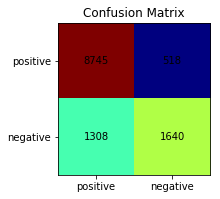

In [17]:
conf_arr =confusion_matrix(y_test,y_pred)

norm_conf = []
for i in conf_arr:
    a = 0
    tmp_arr = []
    a = sum(i, 0)
    for j in i:
        tmp_arr.append(float(j)/float(a))
    norm_conf.append(tmp_arr)

fig = plt.figure()
plt.clf()
ax = fig.add_subplot(1,2,1)
ax.set_aspect(1)
res = ax.imshow(np.array(norm_conf), cmap=plt.cm.jet, 
                interpolation='nearest')
width, height = conf_arr.shape

for x in range(width):
    for y in range(height):
        ax.annotate(str(conf_arr[x][y]), xy=(y, x), 
                    horizontalalignment='center',
                    verticalalignment='center')

plt.title("Confusion Matrix")
plt.xticks(range(width), ['positive','negative'])
plt.yticks(range(height), ['positive','negative'])
plt.show()

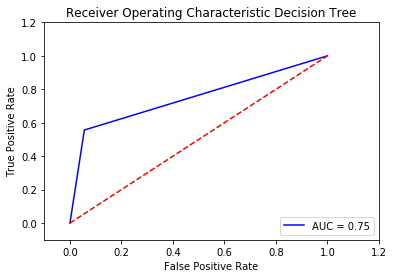

In [18]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(false_positive_rate, true_positive_rate)

plt.title('Receiver Operating Characteristic Decision Tree')
plt.plot(false_positive_rate, true_positive_rate, 'b',label='AUC = %0.2f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([-0.1,1.2])
plt.ylim([-0.1,1.2])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [20]:
Gini_coefficient_gini=2*roc_auc - 1
print("Gini_coefficient of both the Decision Tree classifier models are\n")
print("Gini Index=",Gini_coefficient_gini)

Gini_coefficient of both the Decision Tree classifier models are

Gini Index= 0.5003879545282428
